In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('data/phising_data.csv')

In [3]:
df.corr()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
having_IP_Address,1.000000,-0.052411,0.403461,0.158699,0.397389,-0.005257,-0.080745,0.071414,-0.022739,0.087025,...,0.096882,0.054694,-0.010446,-0.050733,0.002922,-0.091774,0.029153,-0.339065,-0.019103,0.094160
URL_Length,-0.052411,1.000000,-0.097881,-0.075108,-0.081247,0.055247,0.003997,0.048754,-0.221892,-0.042497,...,-0.049381,-0.013838,0.179426,-0.040823,0.008993,0.183518,0.002902,-0.022987,-0.067153,0.057430
Shortining_Service,0.403461,-0.097881,1.000000,0.104447,0.842796,-0.080471,-0.041916,-0.061426,0.060923,0.006101,...,0.036616,0.016581,-0.052596,0.436064,-0.047074,0.014591,0.155844,-0.198410,0.085461,-0.067966
having_At_Symbol,0.158699,-0.075108,0.104447,1.000000,0.086960,-0.011726,-0.058976,0.031220,0.015522,0.304899,...,0.290893,0.284410,-0.005499,-0.047872,0.032918,-0.064735,0.037061,-0.006080,-0.080357,0.052948
double_slash_redirecting,0.397389,-0.081247,0.842796,0.086960,1.000000,-0.085590,-0.043079,-0.036200,0.047464,0.035100,...,0.054463,0.010459,-0.050107,0.431409,-0.062369,-0.003132,0.178415,-0.194165,0.070390,-0.038608
Prefix_Suffix,-0.005257,0.055247,-0.080471,-0.011726,-0.085590,1.000000,0.087891,0.261391,-0.096799,-0.007504,...,-0.014733,-0.036904,0.074116,-0.016556,0.110598,-0.006834,0.067781,0.067423,-0.002763,0.348606
having_Sub_Domain,-0.080745,0.003997,-0.041916,-0.058976,-0.043079,0.087891,1.000000,0.267649,-0.082839,-0.016704,...,-0.025312,0.010637,0.119254,0.125493,-0.005764,0.120730,0.057673,-0.010526,0.081627,0.298323
SSLfinal_State,0.071414,0.048754,-0.061426,0.031220,-0.036200,0.261391,0.267649,1.000000,-0.193622,-0.014757,...,-0.013005,-0.002773,0.162809,0.050972,0.258768,0.074545,0.096051,-0.011710,0.063411,0.714741
Domain_registeration_length,-0.022739,-0.221892,0.060923,0.015522,0.047464,-0.096799,-0.082839,-0.193622,1.000000,0.054253,...,0.051410,0.004393,-0.062851,-0.010477,-0.134454,-0.059898,-0.039766,0.122672,-0.002212,-0.225789
Favicon,0.087025,-0.042497,0.006101,0.304899,0.035100,-0.007504,-0.016704,-0.014757,0.054253,1.000000,...,0.939633,0.627607,-0.002628,0.088211,-0.050922,0.011699,-0.016668,-0.127243,0.300917,-0.000280


<Axes: >

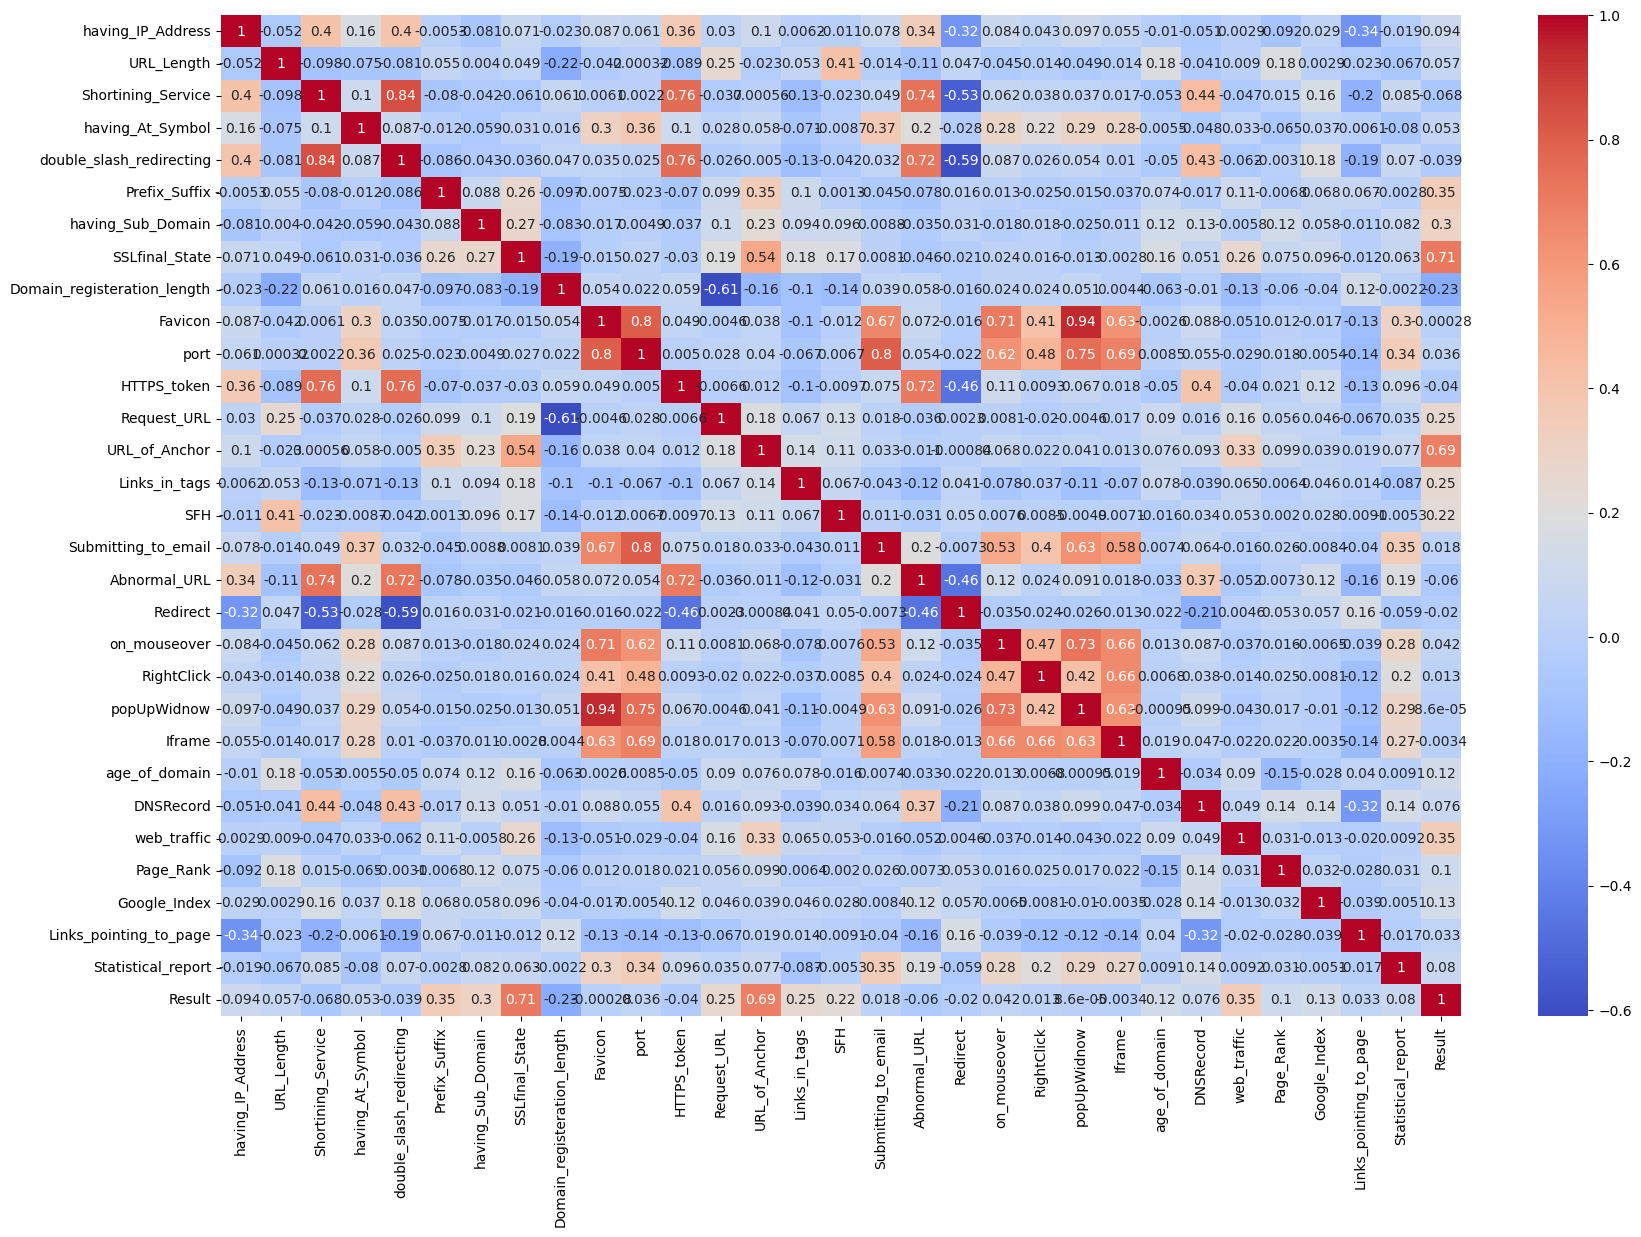

In [6]:
plt.figure(figsize=(20,13))
sns.heatmap(df.corr(),annot = True, cmap='coolwarm')

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif['features'] = df.columns

vif['vif'] = [variance_inflation_factor(df.values,i) for i in range(df.shape[1])]

vif

,features,vif
0,having_IP_Address,1.936163
1,URL_Length,2.526519
2,Shortining_Service,9.878833
3,having_At_Symbol,2.791475
4,double_slash_redirecting,10.639575
5,Prefix_Suffix,2.420501
6,having_Sub_Domain,1.204401
7,SSLfinal_State,2.256701
8,Domain_registeration_length,1.838384
9,Favicon,17.988731


In [11]:
for i,j in  zip(vif['features'], vif['vif']):
    if j>10:
        print(f"{i} : {j}")

double_slash_redirecting : 10.63957484350063
Favicon : 17.988730940405592
port : 11.348737036904813
popUpWidnow : 15.260178828101152


In [15]:
for i,j in zip(vif['features'],vif['vif']):
    if j>10:
        df.drop(columns=i,inplace=True)

In [16]:
df.columns

Index(['having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'Prefix_Suffix', 'having_Sub_Domain',
       'SSLfinal_State', 'Domain_registeration_length', 'HTTPS_token',
       'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH',
       'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover',
       'RightClick', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic',
       'Page_Rank', 'Google_Index', 'Links_pointing_to_page',
       'Statistical_report', 'Result'],
      dtype='object')

In [17]:
df.shape

(11055, 27)

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif['features'] = df.columns

vif['vif'] = [variance_inflation_factor(df.values,i) for i in range(df.shape[1])]
vif

,features,vif
0,having_IP_Address,1.899870
1,URL_Length,2.513876
2,Shortining_Service,7.710733
3,having_At_Symbol,2.708676
4,Prefix_Suffix,2.389529
5,having_Sub_Domain,1.202753
6,SSLfinal_State,2.251693
7,Domain_registeration_length,1.832363
8,HTTPS_token,5.228783
9,Request_URL,1.758002


In [20]:
for i,j in  zip(vif['features'], vif['vif']):
    if j>10:
        print(f"{i} : {j}")

In [21]:
# Save the updated dataset
df.to_csv('data/phising_data_updated.csv', index=False)
print("Dataset saved successfully!")

Dataset saved successfully!
